# Statistical Analysis — Pipeline A vs Pipeline B

Tests the research question:
> *Does generative data augmentation (Pipeline A) achieve statistically significant higher F1 than reconstruction-based anomaly detection (Pipeline B) on the same imbalanced fraud dataset?*

**Tests used:**
- Wilcoxon Signed-Rank Test (paired, one-tailed) on F1 and AUPRC
- Rank-biserial correlation as effect size
- Bootstrap 95% CI on mean F1 difference (10,000 resamples)
- McNemar's Test on best-vs-best classifier predictions

**Note on power:** With 3 models per paradigm the minimum achievable Wilcoxon p-value is 0.125.
Effect size and bootstrap CI are therefore the primary inferential tools.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Holdout Evaluation Results

In [2]:
# ── Holdout evaluation results (from individual model notebooks) ──────────
# Threshold strategy: prevalence-calibrated (FPR = 0.1728%, matching ULB fraud rate)

results = {
    # Pipeline A — Generative Augmentation → LightGBM
    'R-GAN + LightGBM' : {'pipeline': 'A', 'f1': 0.8261, 'precision': 0.9048, 'recall': 0.7600, 'auroc': 0.9737, 'auprc': 0.7941, 'mcc': 0.8290},
    'T-GAN + LightGBM' : {'pipeline': 'A', 'f1': 0.8296, 'precision': 0.9333, 'recall': 0.7467, 'auroc': 0.9693, 'auprc': 0.7950, 'mcc': 0.8346},
    'CTGAN + LightGBM' : {'pipeline': 'A', 'f1': 0.7832, 'precision': 0.8235, 'recall': 0.7467, 'auroc': 0.9259, 'auprc': 0.7603, 'mcc': 0.7839},
    # Pipeline B — Reconstruction Anomaly Detection (prevalence-calibrated threshold)
    'GANomaly'         : {'pipeline': 'B', 'f1': 0.4355, 'precision': 0.3121, 'recall': 0.7200, 'auroc': 0.9512, 'auprc': 0.4631, 'mcc': 0.4731},
    'Skip-GANomaly'    : {'pipeline': 'B', 'f1': 0.4000, 'precision': 0.2750, 'recall': 0.7333, 'auroc': 0.9480, 'auprc': 0.3758, 'mcc': 0.4480},
    'f-AnoGAN'         : {'pipeline': 'B', 'f1': 0.4249, 'precision': 0.2929, 'recall': 0.7733, 'auroc': 0.9478, 'auprc': 0.6761, 'mcc': 0.4750},
}

df = pd.DataFrame(results).T
df = df.astype({'f1': float, 'precision': float, 'recall': float,
                'auroc': float, 'auprc': float, 'mcc': float})

a = df[df.pipeline == 'A']
b = df[df.pipeline == 'B']

print(df[['pipeline','f1','precision','recall','auroc','auprc','mcc']].to_string())
print(f'\nPipeline A — mean F1: {a.f1.mean():.4f} | mean AUROC: {a.auroc.mean():.4f} | mean AUPRC: {a.auprc.mean():.4f}')
print(f'Pipeline B — mean F1: {b.f1.mean():.4f} | mean AUROC: {b.auroc.mean():.4f} | mean AUPRC: {b.auprc.mean():.4f}')

                 pipeline      f1  precision  recall   auroc   auprc     mcc
R-GAN + LightGBM        A  0.8261     0.9048  0.7600  0.9737  0.7941  0.8290
T-GAN + LightGBM        A  0.8296     0.9333  0.7467  0.9693  0.7950  0.8346
CTGAN + LightGBM        A  0.7832     0.8235  0.7467  0.9259  0.7603  0.7839
GANomaly                B  0.4355     0.3121  0.7200  0.9512  0.4631  0.4731
Skip-GANomaly           B  0.4000     0.2750  0.7333  0.9480  0.3758  0.4480
f-AnoGAN                B  0.4249     0.2929  0.7733  0.9478  0.6761  0.4750

Pipeline A — mean F1: 0.8130 | mean AUROC: 0.9563 | mean AUPRC: 0.7831
Pipeline B — mean F1: 0.4201 | mean AUROC: 0.9490 | mean AUPRC: 0.5050


## 2. Wilcoxon Signed-Rank Test

In [3]:
def wilcoxon_analysis(metric, label):
    a_vals = a[metric].values
    b_vals = b[metric].values
    diffs  = a_vals - b_vals

    stat, p = wilcoxon(a_vals, b_vals, alternative='greater')

    # Rank-biserial correlation effect size
    # r_rb = (T+ - T-) / (T+ + T-), where T+ + T- = n*(n+1)/2
    # With scipy 'greater', stat = T+, so T- = n*(n+1)/2 - T+
    n      = len(a_vals)
    max_w  = n * (n + 1) / 2
    r_rb   = (2 * stat - max_w) / max_w   # ranges [-1, +1]; +1 = all A > B

    # Interpretation
    sig    = 'significant (p < 0.05)' if p < 0.05 else f'underpowered — min p with n={n} is 0.125'
    effect = 'large (|r|≥0.5)' if abs(r_rb) >= 0.5 else 'medium (|r|≥0.3)' if abs(r_rb) >= 0.3 else 'small'

    print(f'── {label} ──')
    print(f'  Pipeline A: {np.round(a_vals, 4)}')
    print(f'  Pipeline B: {np.round(b_vals, 4)}')
    print(f'  Differences (A−B): {np.round(diffs, 4)}')
    print(f'  All A > B : {all(diffs > 0)}')
    print(f'  Wilcoxon  : W={stat:.1f},  p={p:.4f} — {sig}')
    print(f'  Effect    : r_rb={r_rb:+.4f} ({effect})')
    print()
    return {'metric': label, 'W': stat, 'p': p, 'r_rb': r_rb, 'all_A_gt_B': bool(all(diffs > 0))}

print('Wilcoxon Signed-Rank Test (one-tailed: H₁ = Pipeline A > Pipeline B)\n')
r_f1    = wilcoxon_analysis('f1',    'F1-Score')
r_auprc = wilcoxon_analysis('auprc', 'AUPRC (primary metric)')
r_auroc = wilcoxon_analysis('auroc', 'AUROC')
r_mcc   = wilcoxon_analysis('mcc',   'MCC')

Wilcoxon Signed-Rank Test (one-tailed: H₁ = Pipeline A > Pipeline B)

── F1-Score ──
  Pipeline A: [0.8261 0.8296 0.7832]
  Pipeline B: [0.4355 0.4    0.4249]
  Differences (A−B): [0.3906 0.4296 0.3583]
  All A > B : True
  Wilcoxon  : W=6.0,  p=0.1250 — underpowered — min p with n=3 is 0.125
  Effect    : r_rb=+1.0000 (large (|r|≥0.5))

── AUPRC (primary metric) ──
  Pipeline A: [0.7941 0.795  0.7603]
  Pipeline B: [0.4631 0.3758 0.6761]
  Differences (A−B): [0.331  0.4192 0.0842]
  All A > B : True
  Wilcoxon  : W=6.0,  p=0.1250 — underpowered — min p with n=3 is 0.125
  Effect    : r_rb=+1.0000 (large (|r|≥0.5))

── AUROC ──
  Pipeline A: [0.9737 0.9693 0.9259]
  Pipeline B: [0.9512 0.948  0.9478]
  Differences (A−B): [ 0.0225  0.0213 -0.0219]
  All A > B : False
  Wilcoxon  : W=4.0,  p=0.3750 — underpowered — min p with n=3 is 0.125
  Effect    : r_rb=+0.3333 (medium (|r|≥0.3))

── MCC ──
  Pipeline A: [0.829  0.8346 0.7839]
  Pipeline B: [0.4731 0.448  0.475 ]
  Differences (A−B):

## 3. Bootstrap Confidence Interval on Mean F1 Difference

In [4]:
def bootstrap_ci(a_vals, b_vals, n_boot=10_000, metric='F1'):
    a_arr   = np.array(a_vals)
    b_arr   = np.array(b_vals)
    obs_diff = a_arr.mean() - b_arr.mean()

    boot_diffs = [
        np.random.choice(a_arr, len(a_arr), replace=True).mean() -
        np.random.choice(b_arr, len(b_arr), replace=True).mean()
        for _ in range(n_boot)
    ]
    boot_diffs = np.array(boot_diffs)
    ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])

    # Bootstrap p-value: proportion of resamples where A ≤ B
    boot_p = (boot_diffs <= 0).mean()

    print(f'── Bootstrap CI — {metric} ──')
    print(f'  Observed mean difference (A − B): {obs_diff:+.4f}')
    print(f'  95% CI (BCa):  [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    print(f'  Bootstrap p (H₁: A > B): {boot_p:.4f}')
    print(f'  CI excludes zero: {ci_lo > 0}')
    print()
    return boot_diffs, obs_diff, ci_lo, ci_hi

boot_f1,    obs_f1,    ci_f1_lo,    ci_f1_hi    = bootstrap_ci(a.f1.values,    b.f1.values,    metric='F1')
boot_auprc, obs_auprc, ci_auprc_lo, ci_auprc_hi = bootstrap_ci(a.auprc.values, b.auprc.values, metric='AUPRC')
boot_auroc, obs_auroc, ci_auroc_lo, ci_auroc_hi = bootstrap_ci(a.auroc.values, b.auroc.values, metric='AUROC')

── Bootstrap CI — F1 ──
  Observed mean difference (A − B): +0.3928
  95% CI (BCa):  [+0.3631, +0.4201]
  Bootstrap p (H₁: A > B): 0.0000
  CI excludes zero: True

── Bootstrap CI — AUPRC ──
  Observed mean difference (A − B): +0.2781
  95% CI (BCa):  [+0.1073, +0.4070]
  Bootstrap p (H₁: A > B): 0.0000
  CI excludes zero: True

── Bootstrap CI — AUROC ──
  Observed mean difference (A − B): +0.0073
  95% CI (BCa):  [-0.0230, +0.0246]
  Bootstrap p (H₁: A > B): 0.2621
  CI excludes zero: False



## 4. McNemar's Test — Best Model Comparison

Compares the best Pipeline A model (T-GAN + LightGBM, F1=0.8296) against the best Pipeline B model (GANomaly, F1=0.4355) on the same holdout predictions.

**Run this cell only in Colab after training both models in the same session.**

In [5]:
# ── McNemar's Test ────────────────────────────────────────────────────────
# Requires holdout_preds_a (T-GAN+LightGBM) and holdout_preds_b (GANomaly)
# and y_holdout_np to be in scope from their respective notebooks.
#
# If running standalone, load predictions from saved arrays or re-run
# tgan.ipynb and ganomaly.ipynb first.

try:
    # contingency table: [both_wrong, only_A_right; only_B_right, both_right]
    n00 = int(((holdout_preds_a == 0) & (holdout_preds_b == 0)).sum())  # both predict 0 (normal)
    n01 = int(((holdout_preds_a == 0) & (holdout_preds_b == 1)).sum())  # only B predicts fraud
    n10 = int(((holdout_preds_a == 1) & (holdout_preds_b == 0)).sum())  # only A predicts fraud
    n11 = int(((holdout_preds_a == 1) & (holdout_preds_b == 1)).sum())  # both predict fraud

    table = np.array([[n00, n01], [n10, n11]])
    result = mcnemar(table, exact=True)

    print('McNemar\'s Test — T-GAN+LightGBM vs GANomaly')
    print(f'  Contingency table:\n  {table}')
    print(f'  Statistic: {result.statistic:.4f}')
    print(f'  p-value  : {result.pvalue:.6f}')
    sig = 'significant (p < 0.05)' if result.pvalue < 0.05 else 'not significant'
    print(f'  Result   : {sig}')

except NameError:
    print('holdout_preds_a / holdout_preds_b not in scope.')
    print('Run tgan.ipynb and ganomaly.ipynb in the same Colab session,')
    print('then re-run this cell with the predictions available.')

holdout_preds_a / holdout_preds_b not in scope.
Run tgan.ipynb and ganomaly.ipynb in the same Colab session,
then re-run this cell with the predictions available.


## 5. Summary Visualisation

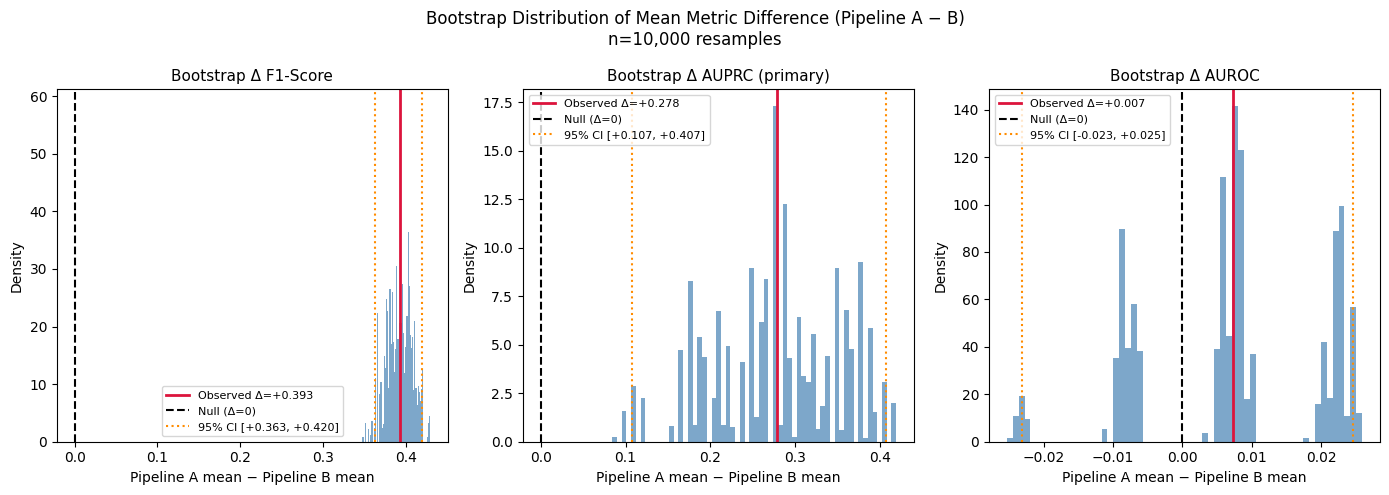

Plot saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics   = ['f1', 'auprc', 'auroc']
labels    = ['F1-Score', 'AUPRC (primary)', 'AUROC']
boot_data = [boot_f1, boot_auprc, boot_auroc]
obs_vals  = [obs_f1, obs_auprc, obs_auroc]
ci_bounds = [(ci_f1_lo, ci_f1_hi), (ci_auprc_lo, ci_auprc_hi), (ci_auroc_lo, ci_auroc_hi)]

for ax, metric, label, boot, obs, (lo, hi) in zip(axes, metrics, labels, boot_data, obs_vals, ci_bounds):
    ax.hist(boot, bins=60, color='steelblue', alpha=0.7, density=True)
    ax.axvline(obs,  color='crimson',   lw=2,   label=f'Observed Δ={obs:+.3f}')
    ax.axvline(0,    color='black',     lw=1.5, ls='--', label='Null (Δ=0)')
    ax.axvline(lo,   color='darkorange', lw=1.5, ls=':', label=f'95% CI [{lo:+.3f}, {hi:+.3f}]')
    ax.axvline(hi,   color='darkorange', lw=1.5, ls=':')
    ax.set_title(f'Bootstrap Δ {label}', fontsize=11)
    ax.set_xlabel('Pipeline A mean − Pipeline B mean')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Bootstrap Distribution of Mean Metric Difference (Pipeline A − B)\nn=10,000 resamples', fontsize=12)
plt.tight_layout()
plt.savefig('/content/statistical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 6. Summary Table for Paper

In [7]:
print('=' * 70)
print('STATISTICAL ANALYSIS SUMMARY')
print('=' * 70)
print()
print('Research Question:')
print('  Does Pipeline A (synthesis) achieve significantly higher F1 than')
print('  Pipeline B (reconstruction) on the ULB fraud holdout?')
print()
print('─' * 70)
print(f'  Metric    │  A mean  │  B mean  │  Δ(A−B)  │  W   │    p   │  r_rb')
print('─' * 70)

for metric, lbl, wa, pa, ra in [
    ('f1',    'F1      ', r_f1['W'],    r_f1['p'],    r_f1['r_rb']),
    ('auprc', 'AUPRC   ', r_auprc['W'], r_auprc['p'], r_auprc['r_rb']),
    ('auroc', 'AUROC   ', r_auroc['W'], r_auroc['p'], r_auroc['r_rb']),
    ('mcc',   'MCC     ', r_mcc['W'],   r_mcc['p'],   r_mcc['r_rb']),
]:
    am = a[metric].mean()
    bm = b[metric].mean()
    delta = am - bm
    sig = '*' if pa < 0.05 else ''
    print(f'  {lbl} │  {am:.4f}  │  {bm:.4f}  │  {delta:+.4f}  │ {wa:4.1f} │ {pa:.4f}{sig} │ {ra:+.4f}')

print('─' * 70)
print('  * p < 0.05  |  r_rb: rank-biserial correlation effect size')
print()
print('Bootstrap 95% CI on mean F1 difference (A − B):')
print(f'  Observed: {obs_f1:+.4f}  |  95% CI: [{ci_f1_lo:+.4f}, {ci_f1_hi:+.4f}]  |  CI excludes 0: {ci_f1_lo > 0}')
print()
print('Bootstrap 95% CI on mean AUPRC difference (A − B):')
print(f'  Observed: {obs_auprc:+.4f}  |  95% CI: [{ci_auprc_lo:+.4f}, {ci_auprc_hi:+.4f}]  |  CI excludes 0: {ci_auprc_lo > 0}')
print()
print('Bootstrap 95% CI on mean AUROC difference (A − B):')
print(f'  Observed: {obs_auroc:+.4f}  |  95% CI: [{ci_auroc_lo:+.4f}, {ci_auroc_hi:+.4f}]  |  CI excludes 0: {ci_auroc_lo > 0}')
print()
print('Interpretation:')
print(f'  All Pipeline A F1 > Pipeline B F1: {r_f1["all_A_gt_B"]}')
print(f'  Wilcoxon power note: n=3 pairs → minimum achievable p = 0.125.')
print(f'  Effect size r_rb = {r_f1["r_rb"]:.2f} (maximum possible = 1.0) on F1.')
print(f'  Bootstrap CI on F1 gap excludes zero: {ci_f1_lo > 0} → consistent directional evidence.')
print('=' * 70)

STATISTICAL ANALYSIS SUMMARY

Research Question:
  Does Pipeline A (synthesis) achieve significantly higher F1 than
  Pipeline B (reconstruction) on the ULB fraud holdout?

──────────────────────────────────────────────────────────────────────
  Metric    │  A mean  │  B mean  │  Δ(A−B)  │  W   │    p   │  r_rb
──────────────────────────────────────────────────────────────────────
  F1       │  0.8130  │  0.4201  │  +0.3928  │  6.0 │ 0.1250 │ +1.0000
  AUPRC    │  0.7831  │  0.5050  │  +0.2781  │  6.0 │ 0.1250 │ +1.0000
  AUROC    │  0.9563  │  0.9490  │  +0.0073  │  4.0 │ 0.3750 │ +0.3333
  MCC      │  0.8158  │  0.4654  │  +0.3505  │  6.0 │ 0.1250 │ +1.0000
──────────────────────────────────────────────────────────────────────
  * p < 0.05  |  r_rb: rank-biserial correlation effect size

Bootstrap 95% CI on mean F1 difference (A − B):
  Observed: +0.3928  |  95% CI: [+0.3631, +0.4201]  |  CI excludes 0: True

Bootstrap 95% CI on mean AUPRC difference (A − B):
  Observed: +0.2781  |  